# US Lapse Prediction PoC — End-to-End How-To + Results

This notebook demonstrates the **how-to workflow** for the project:

1. Verify data artifacts
2. Build features (policy-quarter panel)
3. Train models (LogReg baseline + PyTorch TabularNet)
4. Evaluate and compare performance
5. Show model drivers (coefficients + permutation importance)

It is designed to be runnable locally on CPU.

## Dataset: `uslapseagent` (CASdatasets)

**Source:** The project uses the public `uslapseagent` dataset from the **CASdatasets** R package (Whole Life policies, tied-agent channel, observed over 1995–2008 per dataset documentation).  
The raw dataset is exported locally via `scripts/export_uslapseagent.R` into `data/raw/uslapseagent.csv`.

**What the modeling table represents:**  
This project converts the raw policy-level time-to-event dataset into a **policy-quarter panel** (discrete-time hazard framing).  
Each row in `data/processed/policy_quarter.parquet` is an “as-of” snapshot at a given **tenure quarter** for a policy, with labels indicating whether a termination event occurs **within the next N quarters** (default N=1).

**Key labels in the modeling table:**
- `y_surrender_next`: surrender within next horizon
- `y_death_next`: death within next horizon
- `y_other_next`: other termination within next horizon
- `y_any_next`: any termination within next horizon

**Leakage note (DJIA):**  
The raw dataset includes a `DJIA` field described as “last observed quarterly variation.” Fields described as “last observed” can be subtly leaky depending on how they were constructed, so this PoC **drops DJIA by default**. You can include it with `--include-djia` if you want to test it (or ideally replace with your own public macro joins aligned by `as_of_date`).

## 1) Setup

In [14]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
)

plt.rcParams["figure.dpi"] = 120

REPO_ROOT = Path(".").resolve().parent
DATA_PARQUET = REPO_ROOT / "data" / "processed" / "policy_quarter.parquet"
LOGREG_DIR = REPO_ROOT / "artifacts" / "logreg"
TORCH_DIR = REPO_ROOT / "artifacts" / "torch"

sys.path.append(str(REPO_ROOT / "src"))

print("Repo:", REPO_ROOT)
print("Data:", DATA_PARQUET)
print("LogReg artifacts:", LOGREG_DIR)
print("Torch artifacts:", TORCH_DIR)

# verify modeling table exists
assert DATA_PARQUET.exists(), (
    f"Missing modeling table: {DATA_PARQUET}. "
    "Build it with lapse_poc.data.build_features first."
)

df = pd.read_parquet(DATA_PARQUET)
df.head()

# Basic data sanity checks
print("Rows:", len(df))
print(df["split"].value_counts(dropna=False))

TARGET = "y_surrender_next"  # change if you want y_any_next etc.
assert TARGET in df.columns, f"Target column not found: {TARGET}"

rates = df.groupby("split")[TARGET].mean().sort_index()
rates

Repo: C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc
Data: C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\data\processed\policy_quarter.parquet
LogReg artifacts: C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\artifacts\logreg
Torch artifacts: C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\artifacts\torch
Rows: 858047
split
train    662725
test     127293
val       68029
Name: count, dtype: int64


split
test     0.011595
train    0.012080
val      0.008129
Name: y_surrender_next, dtype: float64

## 2) Train models (optional)

If you already trained models, you can skip this section.
Otherwise, set `RUN_TRAINING=True` to run training from inside this notebook using subprocess calls.

In [7]:
from lapse_poc.utils import run_python_module_stream

RUN_TRAINING = True  # or False

env = {"PYTHONPATH": str(REPO_ROOT / "src")}

if RUN_TRAINING:
    start_time = datetime.now()
    run_python_module_stream(
        "lapse_poc.models.train_logreg",
        args=[
            "--data", str(DATA_PARQUET),
            "--out", str(LOGREG_DIR),
            "--target", TARGET],
        env=env,
    )
    end_time = datetime.now()
    dt = end_time - start_time
    disp_dt = f"{dt.total_seconds():.2f} seconds" if dt.total_seconds() < 60 else f"{dt.total_seconds() / 60:.2f} minutes"
    print(f"LogReg training completed in {disp_dt}")

    start_time = datetime.now()
    run_python_module_stream(
        "lapse_poc.models.train_torch",
        args=[
            "--data", str(DATA_PARQUET),
            "--out", str(TORCH_DIR),
            "--target", TARGET],
        env=env,
    )
    end_time = datetime.now()
    dt = end_time - start_time
    disp_dt = f"{dt.total_seconds():.2f} seconds" if dt.total_seconds() < 60 else f"{dt.total_seconds() / 60:.2f} minutes"
    print(f"Torch training completed in {disp_dt}")



CWD: c:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\notebooks
CMD: c:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\.venv\Scripts\python.exe -u -m lapse_poc.models.train_logreg --data C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\data\processed\policy_quarter.parquet --out C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\artifacts\logreg --target y_surrender_next
{
  "train": {
    "pr_auc": 0.017688324488152832,
    "roc_auc": 0.6132892186144872,
    "brier": 0.2406352026161094,
    "precision@0.10": 0.021049613713182036,
    "base_rate": 0.012080425515862537,
    "top_decile_rate": 0.021049613713182036,
    "lift@decile": 1.7424563137732407
  },
  "val": {
    "pr_auc": 0.011320372808215875,
    "roc_auc": 0.5935058471529948,
    "brier": 0.18052854125255616,
    "precision@0.10": 0.012788475672497428,
  

## 3) Load models and compute predictions

We score both models on `val` and `test` splits and store probabilities for comparisons and plots.

In [8]:
import joblib
import torch
from sklearn.pipeline import Pipeline

from lapse_poc.data.preprocessing import TabularPreprocessor
from lapse_poc.models.tabular import TabularNet

SPLITS = ["val", "test"]

df_val = df[df["split"] == "val"].copy()
df_test = df[df["split"] == "test"].copy()

splits = {"val": df_val, "test": df_test}

assert (LOGREG_DIR / "model.joblib").exists(), "Train LogReg first (artifacts/logreg/model.joblib missing)"
assert (TORCH_DIR / "model.pt").exists(), "Train Torch first (artifacts/torch/model.pt missing)"
assert (TORCH_DIR / "preprocessor.joblib").exists(), "Torch preprocessor missing"

# ----- Load LogReg -----
logreg: Pipeline = joblib.load(LOGREG_DIR / "model.joblib")

# ----- Load Torch -----
pre = TabularPreprocessor.from_dict(joblib.load(TORCH_DIR / "preprocessor.joblib"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch_model = TabularNet(cat_cardinalities=pre.cat_cardinalities(), n_num=len(pre.num_cols)).to(device)
state = torch.load(TORCH_DIR / "model.pt", map_location=device)
torch_model.load_state_dict(state)
torch_model.eval()

@torch.no_grad()
def torch_predict_proba(df_in: pd.DataFrame, batch_size: int = 4096) -> np.ndarray:
    X = df_in[pre.cat_cols + pre.num_cols].copy()
    x_cat, x_num = pre.transform(X)
    x_cat = torch.from_numpy(x_cat).to(device)
    x_num = torch.from_numpy(x_num).to(device)
    probs = np.empty(len(df_in), dtype=np.float32)
    for i in range(0, len(df_in), batch_size):
        logits = torch_model(x_cat[i:i+batch_size], x_num[i:i+batch_size])
        probs[i:i+batch_size] = torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32)
    return probs

preds = {}
for split_name, d in splits.items():
    y = d[TARGET].to_numpy(dtype=int)

    # LogReg uses CAT_COLS + NUM_COLS from training script; easiest is to use the pipeline directly
    # It expects the original columns present in df.
    X_lr = d  # pipeline's ColumnTransformer selects the expected columns
    p_lr = logreg.predict_proba(X_lr)[:, 1]

    # Torch uses preprocessor contract
    p_torch = torch_predict_proba(d)

    preds[split_name] = {
        "y": y,
        "logreg": p_lr,
        "torch": p_torch,
    }

for s in SPLITS:
    print(s, "n=", len(preds[s]["y"]), "event_rate=", preds[s]["y"].mean())

val n= 68029 event_rate= 0.008128886210292669
test n= 127293 event_rate= 0.011595295892154321


## 4) Metric summary table (val/test)

In [9]:
def summarize_metrics(y, p):
    out = {
        "pr_auc": average_precision_score(y, p),
        "roc_auc": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "brier": brier_score_loss(y, p),
    }
    return out

rows = []
for split_name in SPLITS:
    y = preds[split_name]["y"]
    for model_name in ["logreg", "torch"]:
        p = preds[split_name][model_name]
        m = summarize_metrics(y, p)
        rows.append({"split": split_name, "model": model_name, **m})

metrics_df = pd.DataFrame(rows)
metrics_df

,split,model,pr_auc,roc_auc,brier
0,val,logreg,0.011320,0.593506,0.180529
1,val,torch,0.011861,0.625801,0.176627
2,test,logreg,0.016558,0.605483,0.161767
3,test,torch,0.018157,0.646178,0.165979


## 5) Precision–Recall curves (val/test)

PR curves are usually the most informative for lapse prediction due to class imbalance.

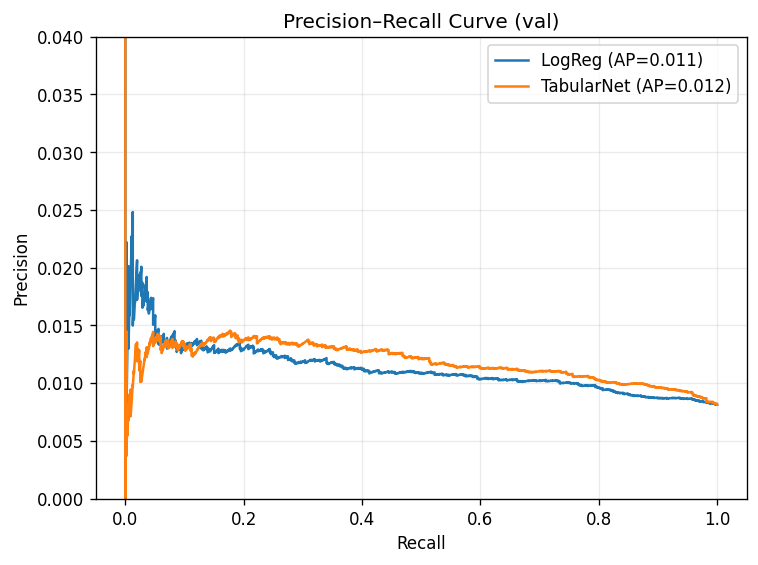

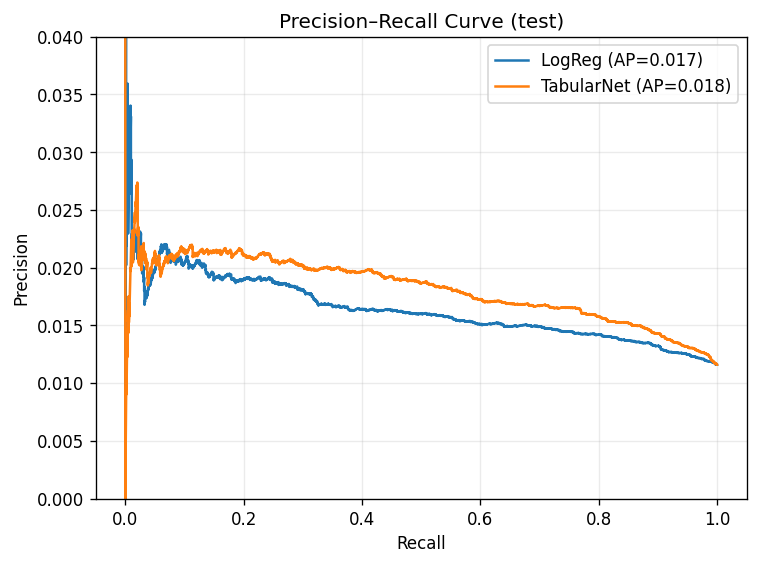

In [20]:
def plot_pr_curves(split_name: str):
    y = preds[split_name]["y"]
    plt.figure(figsize=(7, 5))
    for model_name, label in [("logreg", "LogReg"), ("torch", "TabularNet")]:
        p = preds[split_name][model_name]
        precision, recall, _ = precision_recall_curve(y, p)
        ap = average_precision_score(y, p)
        plt.plot(recall, precision,label=f"{label} (AP={ap:.3f})")
    plt.ylim(0, .04)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve ({split_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.show()

for s in SPLITS:
    plot_pr_curves(s)

## 6) Lift chart (deciles)

Lift is a stakeholder-friendly metric in insurance/retention: it answers **how concentrated events are in the top scores**.

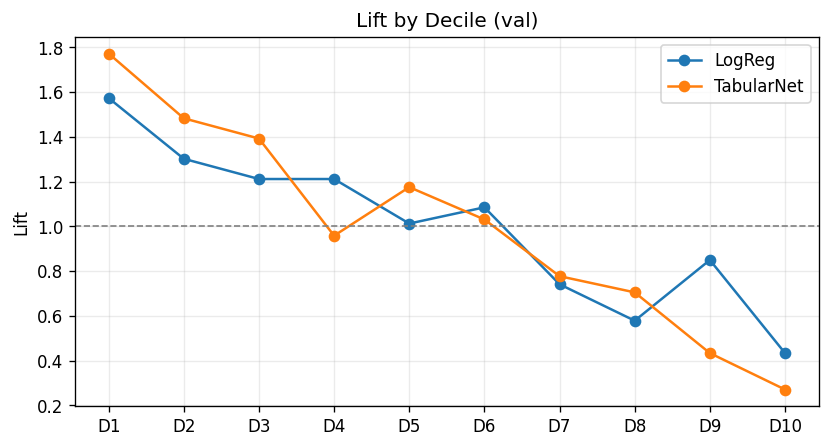

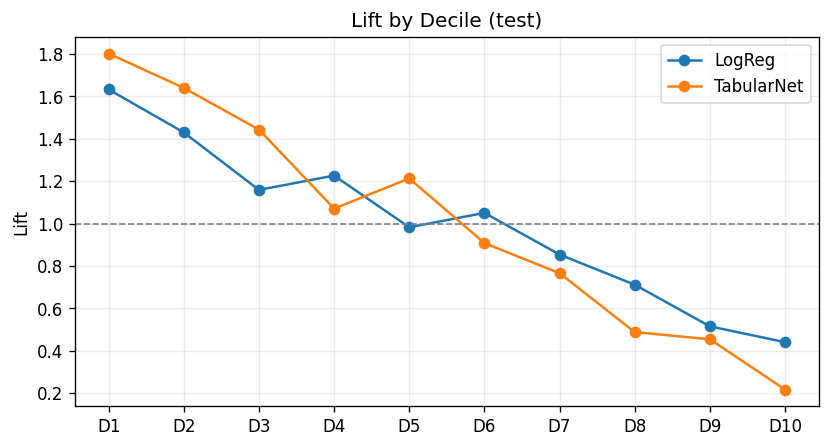

In [11]:
def lift_by_decile(y: np.ndarray, p: np.ndarray, n_bins: int = 10) -> pd.DataFrame:
    dfp = pd.DataFrame({"y": y, "p": p}).sort_values("p", ascending=False).reset_index(drop=True)
    dfp["decile"] = pd.qcut(dfp.index + 1, q=n_bins, labels=[f"D{i}" for i in range(1, n_bins+1)])
    out = dfp.groupby("decile")["y"].agg(["mean", "count"]).rename(columns={"mean": "event_rate"})
    base = dfp["y"].mean()
    out["lift"] = out["event_rate"] / base if base > 0 else np.inf
    out = out.reset_index()
    return out

def plot_lift(split_name: str):
    y = preds[split_name]["y"]
    plt.figure(figsize=(8, 4))
    for model_name, label in [("logreg", "LogReg"), ("torch", "TabularNet")]:
        p = preds[split_name][model_name]
        lift = lift_by_decile(y, p)
        plt.plot(lift["decile"], lift["lift"], marker="o", label=label)
    plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    plt.ylabel("Lift")
    plt.title(f"Lift by Decile ({split_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.show()

for s in SPLITS:
    plot_lift(s)

## 7) Calibration curves + Brier score

Calibration matters for decisioning (threshold selection, expected-value calculations).

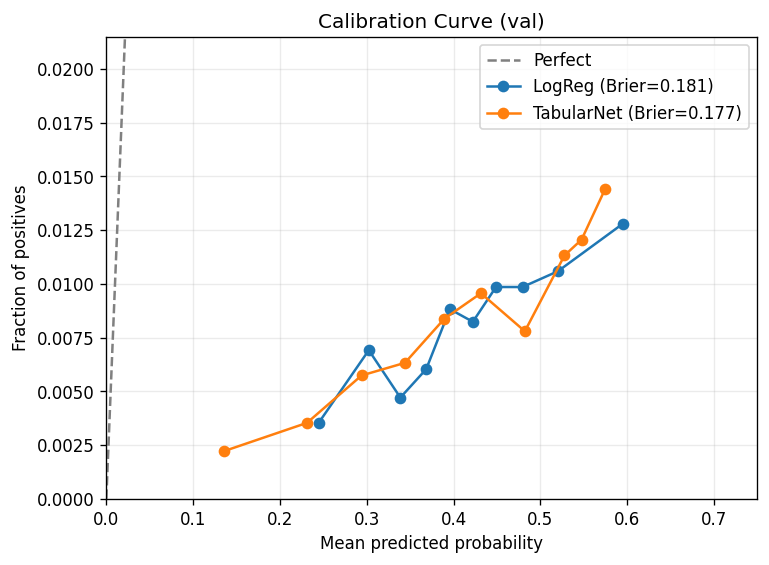

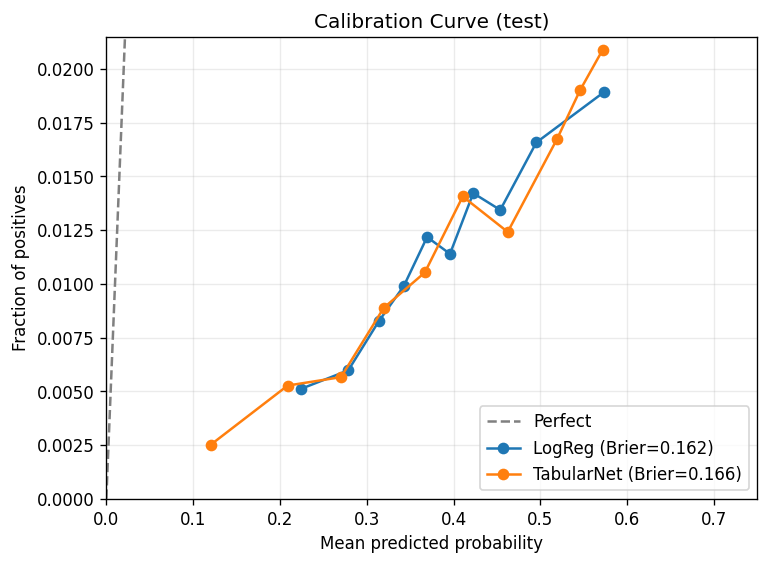

In [24]:
def plot_calibration(split_name: str, n_bins: int = 10):
    y = preds[split_name]["y"]
    plt.figure(figsize=(7, 5))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
    for model_name, label in [("logreg", "LogReg"), ("torch", "TabularNet")]:
        p = preds[split_name][model_name]
        frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
        brier = brier_score_loss(y, p)
        plt.plot(mean_pred, frac_pos, marker="o", label=f"{label} (Brier={brier:.3f})")
    plt.ylim(0,.0215)
    plt.xlim(0, 0.75)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Calibration Curve ({split_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.show()

for s in SPLITS:
    plot_calibration(s)

## 8) Model drivers (tables)

We show two complementary driver views:
- **LogReg coefficients**: directionality + magnitude (interpretability)
- **TabularNet permutation importance**: model-agnostic importance via PR-AUC drop

If the CSVs exist (from the analysis scripts), we load them; otherwise we compute in-notebook.

In [15]:
def get_feature_names(pre: ColumnTransformer) -> list[str]:
    names = []
    for name, transformer, cols in pre.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "get_feature_names_out"):
            fn = transformer.get_feature_names_out(cols)
            names.extend(fn.tolist())
        else:
            names.extend(list(cols))
    return names

def logreg_top_positive(pipe: Pipeline, top_n: int = 10) -> pd.DataFrame:
    pre = pipe.named_steps["pre"]
    clf = pipe.named_steps["clf"]
    names = get_feature_names(pre)
    coefs = clf.coef_.reshape(-1)
    out = pd.DataFrame({"feature": names, "coef": coefs})
    out = out.sort_values("coef", ascending=False).head(top_n).reset_index(drop=True)
    return out

logreg_csv = LOGREG_DIR / "top_positive_coeffs.csv"
if logreg_csv.exists():
    logreg_drivers = pd.read_csv(logreg_csv).head(10)
else:
    logreg_drivers = logreg_top_positive(logreg, top_n=10)

logreg_drivers

,feature,coef,abs_coef
0,premium_frequency_InfraAnnual,0.260731,0.260731
1,annual_premium,0.193399,0.193399
2,underwriting_age_Middle,0.132068,0.132068
3,acc_death_rider_NoRider,0.098208,0.098208
4,living_place_EastCoast,0.052400,0.052400
5,underwriting_age_Young,0.020385,0.020385
6,risk_state_NonSmoker,-0.000026,0.000026
7,living_place_Other,-0.008679,0.008679
8,gender_Male,-0.011316,0.011316
9,premium_frequency_Annual,-0.065264,0.065264


In [16]:
def permutation_importance_pr_auc(
    df_split: pd.DataFrame,
    target: str,
    repeats: int = 3,
    seed: int = 42,
    max_rows: int = 50000,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    d = df_split.copy()

    # cap for speed, keep a reasonable share of positives
    if len(d) > max_rows:
        pos = d[d[target] == 1]
        neg = d[d[target] == 0]
        pos_cap = min(len(pos), max_rows // 2)
        pos_s = pos.sample(n=pos_cap, random_state=seed) if len(pos) > pos_cap else pos
        neg_needed = max_rows - len(pos_s)
        neg_s = neg.sample(n=neg_needed, random_state=seed) if len(neg) > neg_needed else neg
        d = pd.concat([pos_s, neg_s]).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    y = d[target].to_numpy(dtype=int)
    X_base = d[pre.cat_cols + pre.num_cols].copy()

    base_p = torch_predict_proba(d)
    base_pr = float(average_precision_score(y, base_p))

    rows = []
    for col in (pre.cat_cols + pre.num_cols):
        prs = []
        for _ in range(repeats):
            Xp = X_base.copy()
            Xp[col] = rng.permutation(Xp[col].to_numpy())
            # Build a temp df matching torch_predict_proba() expectations
            d_perm = d.copy()
            d_perm[col] = Xp[col]
            p = torch_predict_proba(d_perm)
            prs.append(float(average_precision_score(y, p)))
        rows.append({
            "feature": col,
            "pr_auc_drop_mean": base_pr - float(np.mean(prs)),
            "pr_auc_drop_std": float(np.std(prs, ddof=1)) if len(prs) > 1 else 0.0,
        })

    imp = pd.DataFrame(rows).sort_values("pr_auc_drop_mean", ascending=False).reset_index(drop=True)
    imp.attrs["baseline_pr_auc"] = base_pr
    return imp

perm_csv = TORCH_DIR / "permutation_importance.csv"
if perm_csv.exists():
    tabnet_imp = pd.read_csv(perm_csv).head(10)
    base_pr = None
else:
    full_imp = permutation_importance_pr_auc(df_val, TARGET, repeats=3, seed=42, max_rows=50000)
    base_pr = full_imp.attrs.get("baseline_pr_auc")
    tabnet_imp = full_imp.head(10)

tabnet_imp

,feature,pr_auc_drop_mean,pr_auc_drop_std
0,annual_premium,0.003656,0.000387
1,premium_frequency,0.002579,0.000261
2,underwriting_age,0.001140,0.000220
3,acc_death_rider,0.000402,0.000077
4,risk_state,0.000170,0.000103
5,gender,0.000068,0.000118
6,tenure_qtr,-0.000039,0.000218
7,living_place,-0.000178,0.000087


## 9) Save graphics

This section saves the key plots to `docs/img/`.

In [17]:
OUT_DIR = REPO_ROOT / "docs" / "img"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR

WindowsPath('C:/Users/S88A2T/OneDrive - Swiss Reinsurance Company Ltd/Workspace/Data-Science/us-lapse-poc/docs/img')

In [25]:
def save_pr_curve(split_name: str, path: Path):
    y = preds[split_name]["y"]
    plt.figure(figsize=(7, 5))
    for model_name, label in [("logreg", "LogReg"), ("torch", "TabularNet")]:
        p = preds[split_name][model_name]
        precision, recall, _ = precision_recall_curve(y, p)
        ap = average_precision_score(y, p)
        plt.plot(recall, precision, label=f"{label} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall ({split_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

def save_lift_chart(split_name: str, path: Path):
    y = preds[split_name]["y"]
    plt.figure(figsize=(8, 4))
    for model_name, label in [("logreg", "LogReg"), ("torch", "TabularNet")]:
        p = preds[split_name][model_name]
        lift = lift_by_decile(y, p)
        plt.plot(lift["decile"], lift["lift"], marker="o", label=label)
    plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    plt.ylabel("Lift")
    plt.title(f"Lift by Decile ({split_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

def save_calibration(split_name: str, path: Path, n_bins: int = 10):
    y = preds[split_name]["y"]
    plt.figure(figsize=(7, 5))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
    for model_name, label in [("logreg", "LogReg"), ("torch", "TabularNet")]:
        p = preds[split_name][model_name]
        frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
        brier = brier_score_loss(y, p)
        plt.plot(mean_pred, frac_pos, marker="o", label=f"{label} (Brier={brier:.3f})")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Calibration ({split_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

save_pr_curve("val", OUT_DIR / "pr_curve_val.png")
save_pr_curve("test", OUT_DIR / "pr_curve_test.png")
save_lift_chart("val", OUT_DIR / "lift_val.png")
save_lift_chart("test", OUT_DIR / "lift_test.png")
save_calibration("val", OUT_DIR / "calibration_val.png")
save_calibration("test", OUT_DIR / "calibration_test.png")

print("Saved:")
for p in sorted(OUT_DIR.glob("*.png")):
    print(" -", p)

Saved:
 - C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\docs\img\calibration_test.png
 - C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\docs\img\calibration_val.png
 - C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\docs\img\lift_test.png
 - C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\docs\img\lift_val.png
 - C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\docs\img\pr_curve_test.png
 - C:\Users\S88A2T\OneDrive - Swiss Reinsurance Company Ltd\Workspace\Data-Science\us-lapse-poc\docs\img\pr_curve_val.png


## Done

You can now use the generated images in your README or interview slides:
- `reports/notebook_outputs/pr_curve_val.png`
- `reports/notebook_outputs/pr_curve_test.png`
- `reports/notebook_outputs/lift_val.png`
- `reports/notebook_outputs/lift_test.png`
- `reports/notebook_outputs/calibration_val.png`
- `reports/notebook_outputs/calibration_test.png`

Next step for a stronger portfolio: add **calibration (temperature scaling)** and **budgeted outreach EV curves**.